# Agrupamiento o Clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1) ¿Qué es clustering?

El *clustering* o **agrupamiento** es una técnica de **aprendizaje no supervisado** utilizada para descubrir estructuras en conjuntos de datos que no poseen etiquetas.

El objetivo es formar grupos de manera que:

- las instancias pertenecientes a un mismo grupo sean lo más similares posible entre sí;
- las instancias de grupos diferentes sean lo más distintas posible.

A diferencia de un problema de clasificación, aquí las clases no están definidas previamente. El algoritmo analiza los datos y genera una asignación de cada instancia a un **cluster**.

Los métodos que veremos en esta unidad se apoyan en medidas de similitud o distancia:

- **K-Means**, que representa cada cluster mediante un centroide;
- **agrupamiento jerárquico**, que construye una jerarquía de clusters mediante fusiones o divisiones sucesivas.

## 2) K-Means con datos sintéticos (`make_blobs`)

K-Means busca dividir las instancias en $K$ clusters representados por sus **centroides**.

El procedimiento puede resumirse en cuatro pasos:

1. **Inicialización:** se fija el número de clusters $K$ y se inicializan los centroides.
2. **Asignación:** cada instancia se asigna al centroide más cercano utilizando, habitualmente, distancia euclídea.
3. **Actualización:** cada centroide se reemplaza por la media de las instancias asignadas a su cluster.
4. **Repetición:** los pasos de asignación y actualización se repiten hasta que los centroides dejan de cambiar de manera significativa.

Comenzaremos con un conjunto de datos que se ajusta razonablemente bien a las suposiciones de K-Means: clusters compactos y aproximadamente esféricos.

Primero visualizamos los datos sin utilizar sus etiquetas originales.

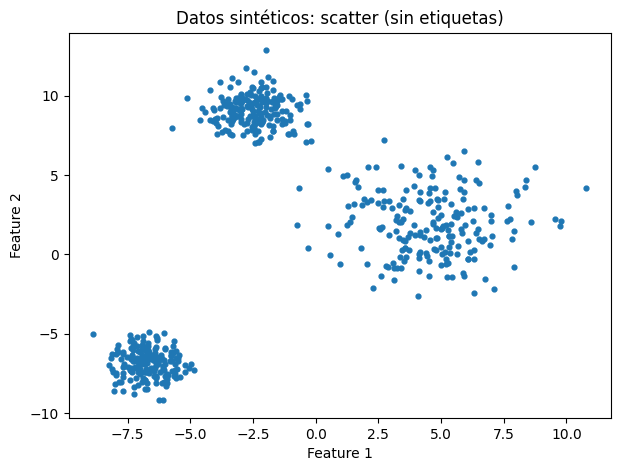

In [2]:
X_blobs, y_blobs = make_blobs(n_samples=600, centers=3, cluster_std=[1.0, 2.0, 0.8], random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=12)
plt.title("Datos sintéticos: scatter (sin etiquetas)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### Ajuste de K-Means

En `scikit-learn`, `n_clusters` fija el valor de $K$. El parámetro `n_init` indica cuántas inicializaciones diferentes se prueban; conservar la mejor solución ayuda a reducir la sensibilidad del método a la posición inicial de los centroides.

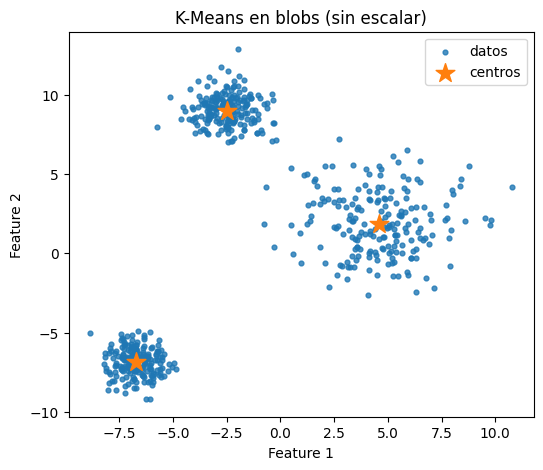

Inercia (WCSS) sin escalar: 2214.9075791438936


In [3]:
kmeans_raw = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_raw = kmeans_raw.fit_predict(X_blobs)
# print(labels_raw)

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=12, alpha=0.8, label="datos")
centers_raw = kmeans_raw.cluster_centers_
plt.scatter(centers_raw[:, 0], centers_raw[:, 1], marker="*", s=200, label="centros")
plt.title("K-Means en blobs (sin escalar)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Inercia (WCSS) sin escalar:", kmeans_raw.inertia_)


### Consideración práctica: escala de las características

K-Means se basa en distancias. Por lo tanto, si las características están expresadas en escalas muy diferentes, una variable puede dominar el cálculo de distancia únicamente por su magnitud numérica.

En este ejemplo también observaremos el resultado después de estandarizar las características mediante *z-score*.

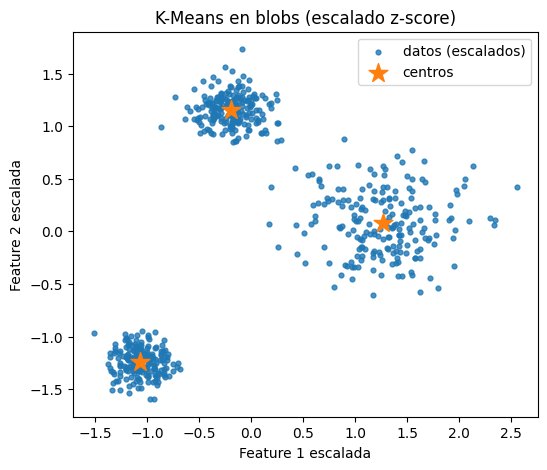

Inercia (WCSS) con escalado: 71.64932998355135


In [4]:
# --- K-Means con escalado (z-score) ---
scaler = StandardScaler()
Xb_scaled = scaler.fit_transform(X_blobs)

kmeans_scaled = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(Xb_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(Xb_scaled[:, 0], Xb_scaled[:, 1], s=12, alpha=0.8, label="datos (escalados)")
centers_scaled = kmeans_scaled.cluster_centers_
plt.scatter(centers_scaled[:, 0], centers_scaled[:, 1], marker="*", s=200, label="centros")
plt.title("K-Means en blobs (escalado z-score)")
plt.xlabel("Feature 1 escalada"); plt.ylabel("Feature 2 escalada")
plt.legend()
plt.show()

print("Inercia (WCSS) con escalado:", kmeans_scaled.inertia_)


### Inercia o WCSS en K-Means

La función de costo utilizada por K-Means se denomina **inercia** o **WCSS** (*Within-Cluster Sum of Squares*). Mide la suma de las distancias cuadráticas entre cada instancia y el centroide del cluster al que fue asignada:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in S_k} \|x_i-c_k\|^2
$$

donde:

- $K$ es el número de clusters;
- $S_k$ es el conjunto de instancias pertenecientes al cluster $k$;
- $x_i$ es una instancia;
- $c_k$ es el centroide del cluster $k$.

K-Means busca que esta cantidad sea lo menor posible. Una WCSS pequeña indica que los puntos están próximos a sus respectivos centroides.

Sin embargo, la WCSS **siempre disminuye al aumentar $K$**, porque disponer de más centroides permite representar los datos con mayor detalle. Por esa razón, no se puede elegir el número de clusters simplemente buscando la WCSS mínima.

### Método del codo

Una estrategia habitual para seleccionar $K$ consiste en ejecutar K-Means para distintos valores de $K$ y observar cómo disminuye la WCSS.

El **método del codo** busca un punto a partir del cual aumentar el número de clusters produce mejoras cada vez menores. Ese cambio de pendiente sugiere un compromiso razonable entre cantidad de clusters y compactación interna.

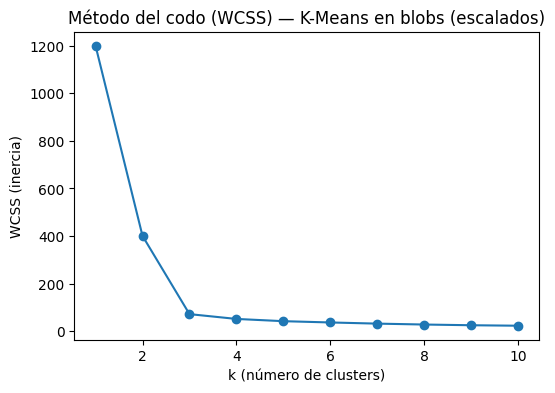

In [5]:
# --- Método del codo en datos escalados ---
K_range = range(1, 11)
wcss = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xb_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Método del codo (WCSS) — K-Means en blobs (escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()


### Otro ejemplo: clusters con diferente dispersión y tamaño

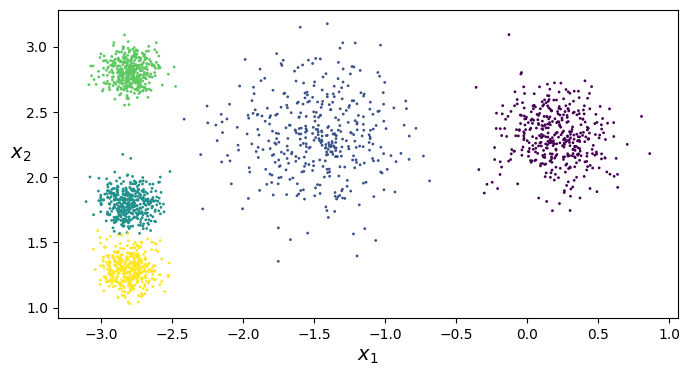

In [6]:
# Veamos otro ejemplo con blobs de diferente densidad y tamaño
blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3]])
blob_std = np.array([0.2, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=1)

plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.show()

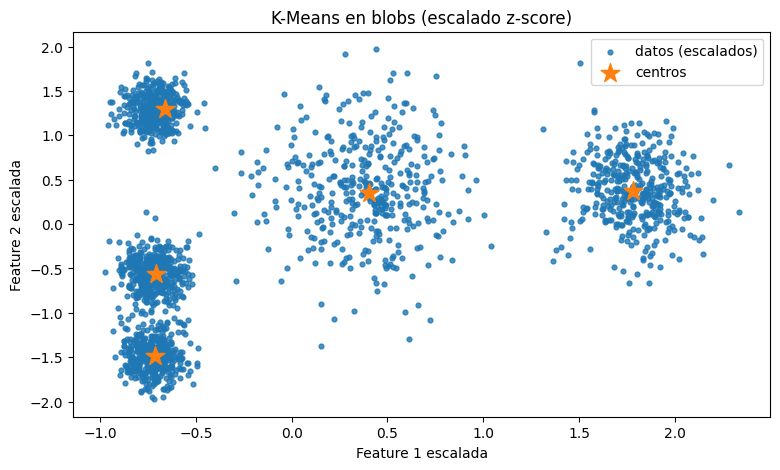

Inercia (WCSS) con escalado: 242.89107703707475


In [7]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

kmeans_sc = KMeans(n_clusters=5, n_init=10, random_state=1)
labels_sc = kmeans_sc.fit_predict(X_sc)

plt.figure(figsize=(9, 5))
plt.scatter(X_sc[:, 0], X_sc[:, 1], s=12, alpha=0.8, label="datos (escalados)")
centers_sc = kmeans_sc.cluster_centers_
plt.scatter(centers_sc[:, 0], centers_sc[:, 1], marker="*", s=200, label="centros")
plt.title("K-Means en blobs (escalado z-score)")
plt.xlabel("Feature 1 escalada"); plt.ylabel("Feature 2 escalada")
plt.legend()
plt.show()

print("Inercia (WCSS) con escalado:", kmeans_sc.inertia_)

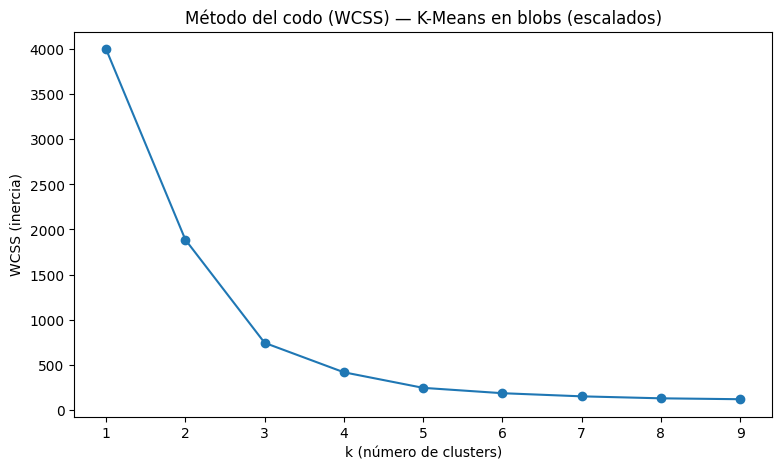

In [8]:
# --- Método del codo en datos escalados ---
kmeans_per_k = [ KMeans(n_clusters=k, n_init=10, random_state=1).fit(X_sc) for k in range(1, 10) ]
wcss_per_k = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(9, 5))
plt.plot(list(range(1, 10)), wcss_per_k, marker="o")
plt.title("Método del codo (WCSS) — K-Means en blobs (escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()


### Análisis de silueta (*Silhouette Analysis*)

El **índice de silueta** evalúa simultáneamente dos propiedades deseables de un agrupamiento: la **cohesión** dentro de cada cluster y la **separación** respecto de los demás clusters.

Para cada instancia $i$ se calculan:

1. $a(i)$: distancia media entre el punto $i$ y los demás puntos de su **mismo cluster**. Representa la cohesión.
2. $b(i)$: distancia media entre el punto $i$ y los puntos del **cluster más cercano al que no pertenece**. Representa la separación.

El coeficiente de silueta de la instancia $i$ es:

$$
s(i) = \frac{b(i)-a(i)}{\max\{a(i),b(i)\}}
$$

Su valor se encuentra entre $-1$ y $1$:

- $s(i)$ cercano a $1$: la instancia está bien integrada en su cluster y separada de los demás;
- $s(i)$ cercano a $0$: la instancia se encuentra cerca de una frontera entre clusters;
- $s(i)<0$: la instancia podría estar mejor asociada a otro cluster.

En `scikit-learn`:

- `silhouette_score(X, labels)` calcula el promedio de los coeficientes de silueta;
- `silhouette_samples(X, labels)` devuelve el valor individual para cada instancia.

El índice de silueta puede utilizarse como criterio complementario al método del codo para analizar distintos valores de $K$.

In [9]:
silhouette_scores = [silhouette_score(X_sc, model.labels_) for model in kmeans_per_k[1:]] #por lo menos 2 clusters
silhouette_scores

[0.5236151635982419,
 0.6237422868321257,
 0.6529167992957435,
 0.6675447165126006,
 0.6563189752159775,
 0.6102725247738214,
 0.6074040611490756,
 0.6021909706141628]

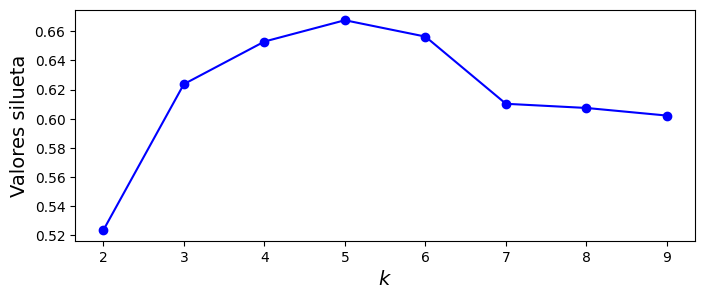

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Valores silueta", fontsize=14)
plt.show()

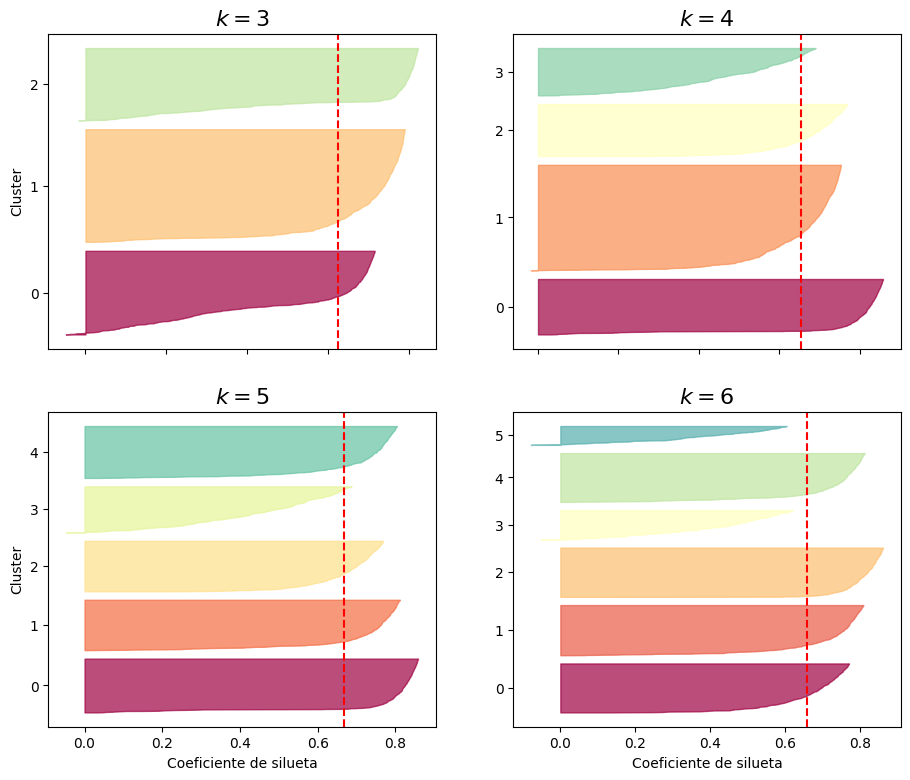

In [11]:
import matplotlib as mpl
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_ #etiquetas de cada instancia de X
    silhouette_coefficients = silhouette_samples(X_sc, y_pred) #coeficientes para cada una de las instancias en X

    padding = len(X) // 30

    pos = padding
    ticks = []
    #Grafico los coeficientes de silueta por cada cluster
    for i in range(k): #i = 0,1,2..
        coeffs = silhouette_coefficients[y_pred == i] #coeficientes correspondientes a un cluster específico
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) #colormap
        plt.fill_betweenx(y = np.arange(pos, pos + len(coeffs)), x1=0, x2=coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        # plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Coeficiente de silueta")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

### ¿Cómo interpretar un diagrama de silueta?

El diagrama de silueta permite evaluar no solo la calidad global del agrupamiento, sino también cómo se comportan los puntos dentro de cada cluster.

Cada franja corresponde a un cluster y cada línea horizontal representa el coeficiente de silueta de una observación. Cuanto más se extiende una línea hacia la derecha, mejor asignado se encuentra ese punto a su cluster.

La línea vertical indica el coeficiente de silueta promedio de todo el agrupamiento.

Al analizar el gráfico conviene observar:

Valores cercanos a 1: indican puntos bien agrupados, próximos a otros elementos de su cluster y alejados de los demás clusters.
Valores cercanos a 0: corresponden a puntos próximos a la frontera entre dos clusters; su asignación es menos clara.
Valores negativos: indican que el punto podría estar mejor ubicado en otro cluster.
Ancho de cada franja: refleja aproximadamente cuántos puntos contiene cada cluster. Diferencias importantes pueden indicar clusters de tamaños muy distintos.
Distribución dentro de cada cluster: un buen agrupamiento debería presentar la mayor parte de sus coeficientes positivos y, preferentemente, por encima o próximos al promedio global.

Para comparar distintas elecciones de $K$, no conviene mirar únicamente el valor promedio de silueta. También es importante observar la forma de los diagramas. Una solución suele considerarse más adecuada cuando presenta un promedio alto, pocos o ningún valor negativo y clusters con coeficientes de silueta razonablemente altos.

> El índice de silueta es una herramienta de apoyo para elegir el número de clusters, pero no determina por sí solo cuál es la partición correcta. Debe interpretarse junto con la estructura de los datos, el método del codo y el conocimiento del problema.

## 3) Limitaciones de K-Means

K-Means es un método simple y computacionalmente eficiente, pero su funcionamiento depende de la geometría de los datos y de la distancia utilizada.

### Sensibilidad a la inicialización

La función de costo de K-Means puede presentar diferentes soluciones locales. Si los centroides se inicializan en posiciones poco favorables, el algoritmo puede converger a una solución subóptima. Por esta razón se suelen realizar varias inicializaciones y conservar la de menor WCSS.

### Sensibilidad a valores atípicos

Los centroides se calculan mediante la media de las instancias de cada cluster. Un valor muy alejado puede desplazar fuertemente esa media y modificar la posición del centroide.

### Forma de los clusters

K-Means funciona especialmente bien cuando los clusters son compactos y aproximadamente esféricos bajo la métrica utilizada. Cuando los grupos tienen formas curvas, alargadas o muy diferentes, la partición obtenida puede no representar adecuadamente la estructura que observamos en los datos.

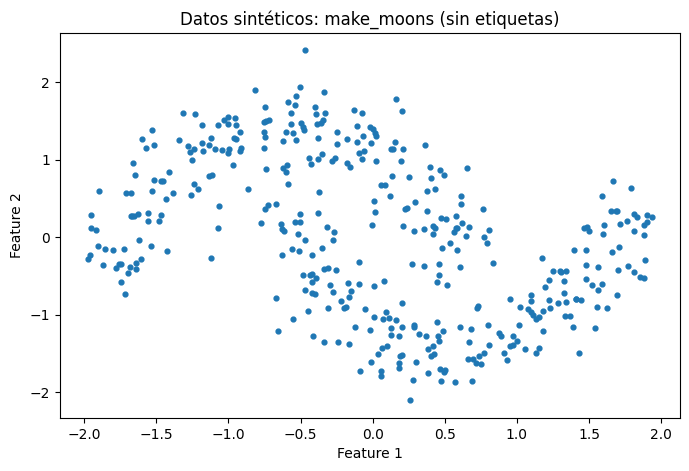

In [12]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.15, random_state=1)
Xm = StandardScaler().fit_transform(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(Xm[:, 0], Xm[:, 1], s=12)
plt.title("Datos sintéticos: make_moons (sin etiquetas)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()


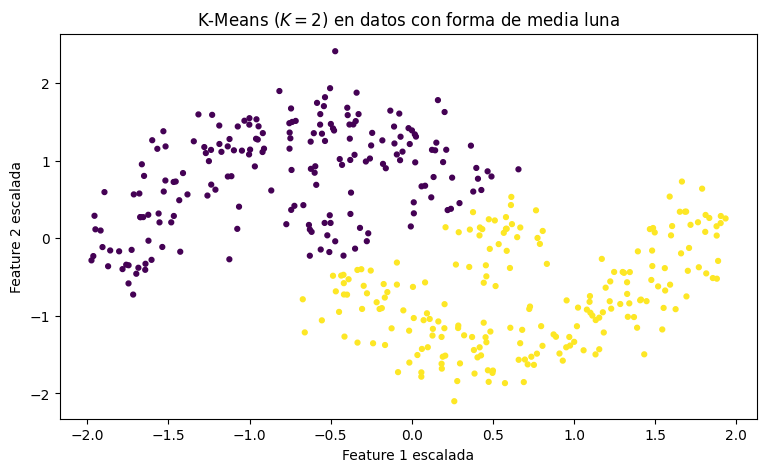

In [13]:
km_m = KMeans(n_clusters=2, n_init=10, random_state=1).fit(Xm)
labels_km = km_m.labels_

plt.figure(figsize=(9, 5))
plt.scatter(Xm[:, 0], Xm[:, 1], s=12, c=labels_km)
plt.title("K-Means ($K=2$) en datos con forma de media luna")
plt.xlabel("Feature 1 escalada")
plt.ylabel("Feature 2 escalada")
plt.show()

### Efecto de la alta dimensionalidad

Cuando aumenta el número de características, el espacio disponible crece rápidamente. Si la cantidad de instancias no aumenta en la misma proporción, los datos se vuelven relativamente más dispersos.

Además, en espacios de alta dimensión las distancias entre instancias tienden a volverse menos discriminativas: las diferencias relativas entre distancias cercanas y lejanas pueden reducirse.

Esto es importante porque tanto K-Means como los métodos jerárquicos estudiados en esta unidad dependen de medidas de distancia. En problemas de alta dimensionalidad, la elección y el tratamiento de las características adquieren especial relevancia.

## 4) Agrupamiento jerárquico

El **agrupamiento jerárquico** construye una jerarquía de clusters. A diferencia de K-Means, no es necesario fijar previamente un único valor de $K$ para construir esa jerarquía: diferentes cortes permiten obtener distintas particiones.

Existen dos enfoques principales:

- **Aglomerativo (*bottom-up*)**: comienza considerando cada instancia como un cluster y fusiona sucesivamente los clusters más próximos.
- **Divisivo (*top-down*)**: comienza con todas las instancias en un único cluster y lo divide sucesivamente en grupos más pequeños.

### Enfoque aglomerativo

El procedimiento general es:

1. cada instancia comienza como un cluster individual;
2. se identifican los dos clusters más próximos;
3. ambos clusters se fusionan;
4. se actualizan las distancias;
5. el proceso se repite hasta obtener un único cluster.

Para decidir qué clusters son los más próximos es necesario definir un **criterio de enlace** (*linkage*). En esta notebook utilizaremos `complete`, para el cual la distancia entre dos clusters $A$ y $B$ se define como:

$$
d(A,B)=\max\{d(x_i,x_j):x_i\in A,\;x_j\in B\}
$$

Es decir, se utiliza la mayor distancia entre un punto de $A$ y un punto de $B$.

### Dendrograma

El resultado puede representarse mediante un **dendrograma**, que muestra el orden en que se producen las fusiones y la distancia a la que ocurren.

Una forma de seleccionar una cantidad de clusters consiste en buscar una separación vertical grande entre fusiones y realizar un corte horizontal dentro de esa separación. El número de ramas interceptadas por el corte determina la cantidad de clusters.

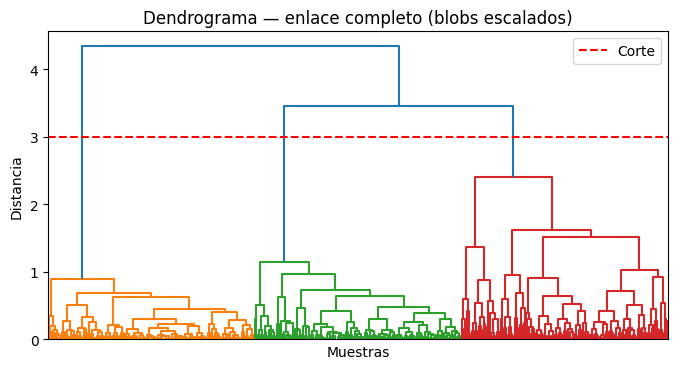

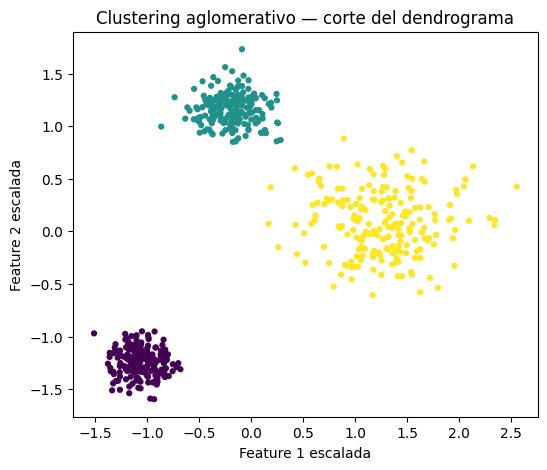

In [14]:
Xh = StandardScaler().fit_transform(X_blobs)

Z = linkage(Xh, method="complete", metric="euclidean")

# Dendrograma
plt.figure(figsize=(8, 4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.axhline(y=3.0, color="red", linestyle="--", label="Corte")
plt.title("Dendrograma — enlace completo (blobs escalados)")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.legend()
plt.show()

# En este ejemplo, un corte alrededor de distancia 3 produce 3 clusters.
hier_labels = fcluster(Z, t=3.0, criterion="distance")

plt.figure(figsize=(6, 5))
plt.scatter(Xh[:, 0], Xh[:, 1], s=12, c=hier_labels)
plt.title("Clustering aglomerativo — corte del dendrograma")
plt.xlabel("Feature 1 escalada")
plt.ylabel("Feature 2 escalada")
plt.show()

También puede obtenerse directamente una partición con `AgglomerativeClustering`. En ese caso sí especificamos la cantidad de clusters que deseamos recuperar a partir de la jerarquía.

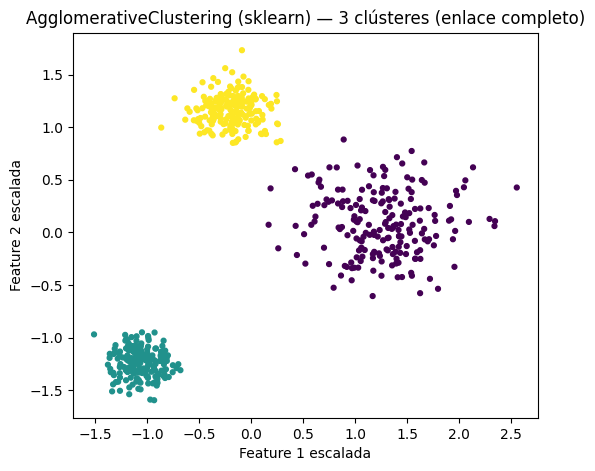

In [15]:
# Usando directamente AgglomerativeClustering de scikit-learn para comparación
ac = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="complete")
labels_ac = ac.fit_predict(Xh)

plt.figure(figsize=(6, 5))
plt.scatter(Xh[:, 0], Xh[:, 1], s=12, c=labels_ac)
plt.title("AgglomerativeClustering (sklearn) — 3 clústeres (enlace completo)")
plt.xlabel("Feature 1 escalada"); plt.ylabel("Feature 2 escalada")
plt.show()


### Enfoque divisivo (*top-down*)

El enfoque divisivo realiza el recorrido inverso al aglomerativo: comienza con todas las instancias dentro de un único cluster y va dividiendo los grupos hasta llegar, en el extremo, a clusters individuales.

Un algoritmo clásico de este tipo es **DIANA** (*DIvisive ANAlysis*). Su idea general es:

1. comenzar con todas las instancias en un mismo cluster;
2. identificar una instancia especialmente alejada del resto y utilizarla para iniciar un nuevo subgrupo;
3. evaluar si otras instancias se encuentran más próximas al nuevo subgrupo que al grupo original y trasladarlas cuando corresponda;
4. repetir el proceso hasta completar la división;
5. continuar dividiendo sucesivamente los clusters.

Tanto el enfoque aglomerativo como el divisivo producen una estructura jerárquica. La diferencia fundamental es la dirección en la que se construye:

$$
\text{Aglomerativo: instancias individuales} \longrightarrow \text{un único cluster}
$$

$$
\text{Divisivo: un único cluster} \longrightarrow \text{instancias individuales}
$$

En esta notebook utilizamos la implementación aglomerativa disponible en `scikit-learn`. El enfoque divisivo no se encuentra disponible en esta biblioteca.